In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
tokenizer

BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}

In [2]:
# !wget https://archive.ics.uci.edu/static/public/176/blood+transfusion+service+center.zip
# !unzip blood+transfusion+service+center.zip

In [3]:
# !unzip census+income.zip

In [4]:
# !pip install openml

In [5]:
import pandas as pd

df = pd.read_csv('transfusion.data', sep=',')
print(len(df))
df

748


,Recency (months),Frequency (times),Monetary (c.c. blood),Time (months),whether he/she donated blood in March 2007
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0
...,...,...,...,...,...
743,23,2,500,38,0
744,21,2,500,52,0
745,23,3,750,62,0
746,39,1,250,39,0


In [6]:
df.columns

Index(['Recency (months)', 'Frequency (times)', 'Monetary (c.c. blood)',
       'Time (months)', 'whether he/she donated blood in March 2007'],
      dtype='object')

In [7]:
import numpy as np
import torch

DROP_P = 0

def concatenate_text(x_full):
    x = {}
    for i, j in x_full.items():
        x[i] = j if np.random.random() > DROP_P else '[UNK]'

    text = "".join([f"I have information about a blood donor. For the first time he donated blood {x['Time (months)']} months ago. ",
           f"Last time he donated blood {x['Recency (months)']} months ago. ",
           f"In total he donated blood {x['Frequency (times)']} times and donated {x['Monetary (c.c. blood)']} cubic centimeters of blood. ",
           f"Will this person donate blood in the next month?"])

    return text

concatenate_text(df.iloc[0])

'I have information about a blood donor. For the first time he donated blood 98 months ago. Last time he donated blood 2 months ago. In total he donated blood 50 times and donated 12500 cubic centimeters of blood. Will this person donate blood in the next month?'

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('whether he/she donated blood in March 2007', axis =1),
                                                    df['whether he/she donated blood in March 2007'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({'yes': 1, 'no': 0})
# y_test = y_test.replace({'yes': 1, 'no': 0})

X_train['label'] = y_train
X_test['label'] = y_test

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

In [9]:
X_train['text'].iloc[0]

'I have information about a blood donor. For the first time he donated blood 49 months ago. Last time he donated blood 9 months ago. In total he donated blood 11 times and donated 2750 cubic centimeters of blood. Will this person donate blood in the next month?'

In [10]:
len(X_train)

598

In [11]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
import evaluate

# Define label mappings
# id2label = {0: "NOT-DONATE", 1: "DONATE"}
# label2id = {"NOT-DONATE": 0, "DONATE": 1}

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

Map:   0%|          | 0/598 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/598 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

In [12]:
import torch
if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")
    

tensor([1.], device='mps:0')


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/200 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 8.7486, 'grad_norm': 19.478328704833984, 'learning_rate': 0.095, 'epoch': 1.0}


  0%|          | 0/3 [00:00<?, ?it/s]

...

test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.7533333333333333
test roc_auc 0.6945706768715619



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.7642140468227425
train roc_auc 0.68538262178562


/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


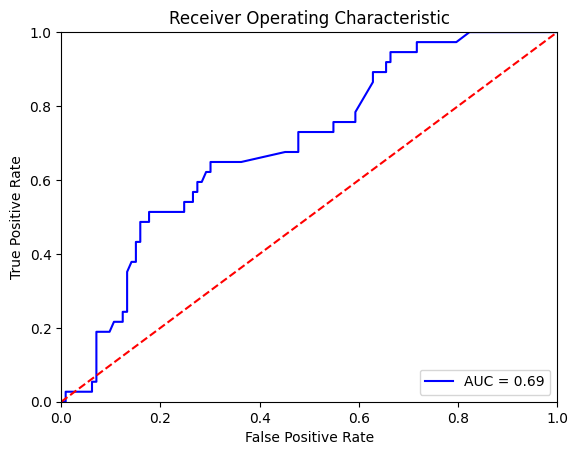

In [13]:
from transformers import BertForSequenceClassification
from transformers import DataCollatorWithPadding
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

def find_best_threshold(y_true, y_pred):
    best_threshold = 0.0
    best_f1 = 0.0
    best_accuracy = 0.0
    
    thresholds = np.arange(0.0, 1.01, 0.01)
    for threshold in thresholds:
        y_pred_binary = (y_pred >= threshold).astype(int)
        
        current_f1 = f1_score(y_true, y_pred_binary)
        
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold
            best_accuracy = accuracy_score(y_true, y_pred_binary)
    
    return best_f1, best_threshold

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.5379, 'grad_norm': 3.5668840408325195, 'learning_rate': 2.0000000000000002e-07, 'epoch': 1.0}


  0%|          | 0/3 [00:00<?, ?it/s]

{'eval_loss': 0.5515488982200623, 'eval_roc_auc': 0.6919397273379574, 'eval_runtime': 2.6569, 'eval_samples_per_second': 56.457, 'eval_steps_per_second': 1.129, 'epoch': 1.0}


...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.37735849056603776
test precision 0.625
test recall 0.2702702702702703
test accuracy 0.78
test roc_auc 0.7132265008371204



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.5156794425087108
train precision 0.5068493150684932
train recall 0.524822695035461
train accuracy 0.7675585284280937
train roc_auc 0.7648866334559337


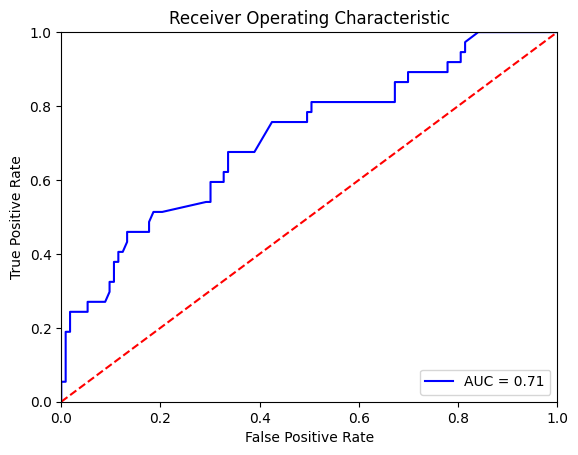

In [14]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [15]:
import pandas as pd

df = pd.read_csv('german.data', sep=' ', names=['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5', 'Attribute6', 'Attribute7', 'Attribute8', 'Attribute9', 'Attribute10', 'Attribute11', 'Attribute12', 'Attribute13', 'Attribute14', 'Attribute15', 'Attribute16', 'Attribute17', 'Attribute18', 'Attribute19', 'Attribute20', 'class'])
print(len(df))
df

1000


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,1
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,1
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,1
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,2


In [16]:
def concatenate_text(x_full):
    x = {}
    for i, j in x_full.items():
        x[i] = j if np.random.random() > DROP_P else '[UNK]'
    
    text = "".join([str(val) + ', ' for val in x.values()])

    return text

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

  0%|          | 0/260 [00:00<?, ?it/s]

...

  0%|          | 0/4 [00:00<?, ?it/s]

test f1 0.8328267477203647
test precision 0.7287234042553191
test recall 0.9716312056737588
test accuracy 0.725
test roc_auc 0.6708739031133549



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/13 [00:00<?, ?it/s]

train f1 0.8226637233259749
train precision 0.69875
train recall 1.0
train accuracy 0.69875
train roc_auc 0.6610797289172277


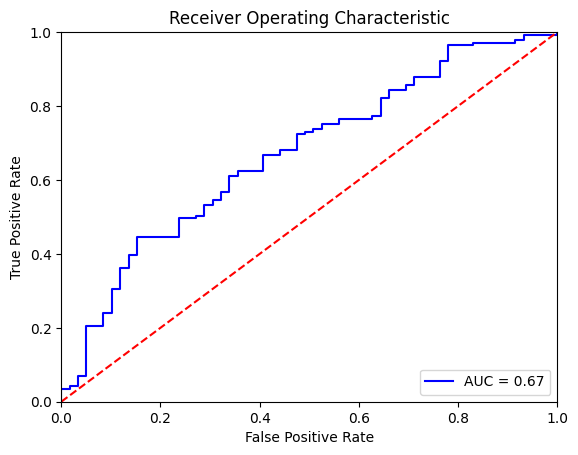

In [17]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('class', axis =1),
                                                    df['class'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({1:1, 2:0})
y_test = y_test.replace({1:1, 2:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/260 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.6215, 'grad_norm': 5.010595798492432, 'learning_rate': 2.0000000000000002e-07, 'epoch': 0.77}


  0%|          | 0/4 [00:00<?, ?it/s]

{'eval_loss': 0.6002791523933411, 'eval_roc_auc': 0.6405818006971992, 'eval_runtime': 3.2219, 'eval_samples_per_second': 62.075, 'eval_steps_per_second': 1.242, 'epoch': 1.0}


...

  0%|          | 0/4 [00:00<?, ?it/s]

test f1 0.8602150537634409
test precision 0.8695652173913043
test recall 0.851063829787234
test accuracy 0.805
test roc_auc 0.8248587570621468



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/13 [00:00<?, ?it/s]

train f1 0.8568994889267462
train precision 0.8178861788617886
train recall 0.8998211091234347
train accuracy 0.79
train roc_auc 0.8205524090885472


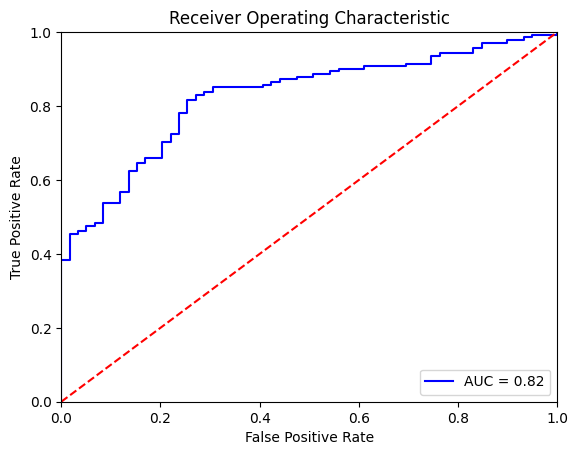

In [18]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [55]:
import pandas as pd

df = pd.read_csv('diabetes.csv')
print(len(df))

def concatenate_text(x_full):
    x = {}
    for i, j in x_full.items():
        x[i] = j if np.random.random() > DROP_P else '[UNK]'
    
    text = "".join([f"I have information about a woman. ",
            f"She has been pregnant {x['Pregnancies']} times. ",
            f"Her plasma glucose concentration in an oral glucose tolerance test is {x['Glucose']}. ",
            f"Her diastolic blood pressure is {x['BloodPressure']} (mm Hg). ",
            f"Her triceps skin fold thickness is {x['SkinThickness']} (mm). ",
            f"Her 2-Hour serum insulin is {x['Insulin']} (mu U/ml). ",
            f"Her body mass index is {x['BMI']}. ",
            f"Her diabetes pedigree function {x['DiabetesPedigreeFunction']}. ",
            f"Her age is {x['Age']} years old."])

    
    return text

X_train, X_test, y_train, y_test = train_test_split(df.drop('Outcome', axis =1),
                                                    df['Outcome'],
                                                    test_size=.2,
                                                    random_state = 42)

768


Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

  0%|          | 0/200 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.6021505376344086
test precision 0.7368421052631579
test recall 0.509090909090909
test accuracy 0.7597402597402597
test roc_auc 0.7869605142332414



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.6385224274406333
train precision 0.7289156626506024
train recall 0.568075117370892
train accuracy 0.7768729641693811
train roc_auc 0.8661562057298069


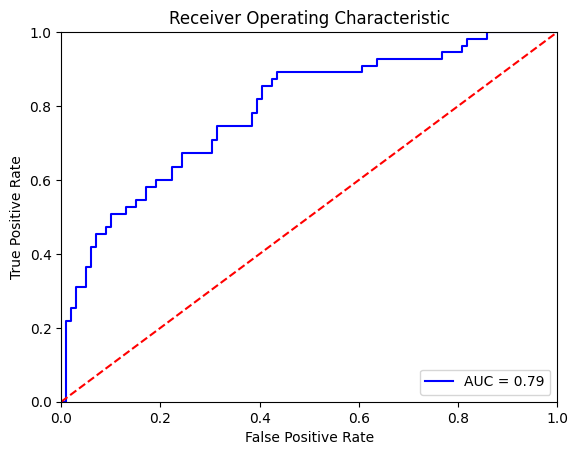

In [56]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('Outcome', axis =1),
                                                    df['Outcome'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({1:1, 2:0})
# y_test = y_test.replace({1:1, 2:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.6722, 'grad_norm': 16.710752487182617, 'learning_rate': 2.0000000000000002e-07, 'epoch': 1.0}


  0%|          | 0/3 [00:00<?, ?it/s]

{'eval_loss': 0.6893337965011597, 'eval_roc_auc': 0.6749311294765841, 'eval_runtime': 2.5548, 'eval_samples_per_second': 60.278, 'eval_steps_per_second': 1.174, 'epoch': 1.0}


...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.6612903225806451
test precision 0.5942028985507246
test recall 0.7454545454545455
test accuracy 0.7272727272727273
test roc_auc 0.7963269054178145



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/10 [00:00<?, ?it/s]

train f1 0.7133757961783439
train precision 0.6511627906976745
train recall 0.7887323943661971
train accuracy 0.7801302931596091
train roc_auc 0.8672684485968178


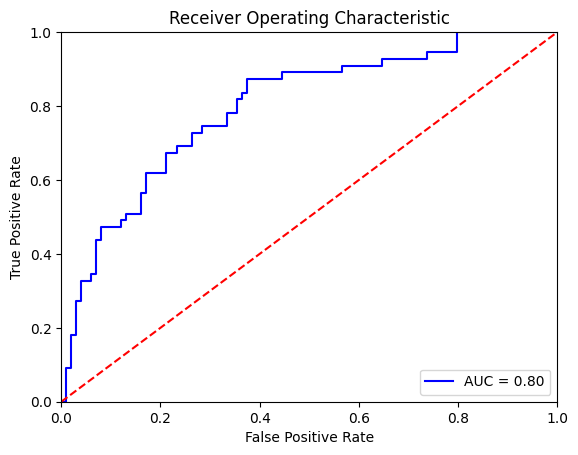

In [21]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv('heart.csv')
print(len(df))

def concatenate_text(x_full):
    x = {}
    for i, j in x_full.items():
        x[i] = j if np.random.random() > DROP_P else '[UNK]'

    if x['ChestPainType'] == 'TA':
        pt = 'Typical Angina'
    elif x['ChestPainType'] == 'ATA':
        pt = 'Atypical Angina'
    elif x['ChestPainType'] == 'NAP':
        pt = 'Non-Anginal Pain'
    elif x['ChestPainType'] == 'ASY':
        pt = 'Asymptomatic'
    else:
        pt = '[UNK]'

    if x['FastingBS'] == 1:
        bs = 'more than 120 mg/dl'
    elif x['FastingBS'] == 1:
        bs = 'less than 120 mg/dl'
    else:
        bs = '[UNK]'

    if x['RestingECG'] == 'Normal':
        ecg = 'Normal'
    elif x['RestingECG'] == 'ST':
        ecg = 'having ST-T wave abnormality'
    elif x['RestingECG'] == 'LVH':
        ecg = 'showing probable or definite left ventricular hypertrophy by Estes criteria'
    else:
        ecg = '[UNK]'
    
    text = "".join([f"I have information about a patient. ",
            f"He is {x['Age']} years old. ",
            f"His sex is {x['Sex']}. ",
            f"His chest pain type is {pt}. ",
            f"His resting blood pressure is {x['RestingBP']} (mm Hg). ",
            f"His serum cholesterol is {x['Cholesterol']} (mm/dl). ",
            f"His fasting blood sugar is {bs}. ",
            f"His resting electrocardiogram results are {ecg}. ",
            f"His maximum heart rate achieved is {x['MaxHR']}. ",
            f"His exercise-induced angina is {x['ExerciseAngina']}. ",
            f"His oldpeak {x['Oldpeak']}. ",
            f"His slope of the peak exercise ST segment is {x['ST_Slope']}."])

    
    return text

X_train, X_test, y_train, y_test = train_test_split(df.drop('HeartDisease', axis =1),
                                                    df['HeartDisease'],
                                                    test_size=.2,
                                                    random_state = 42)

918


Map:   0%|          | 0/734 [00:00<?, ? examples/s]

Map:   0%|          | 0/184 [00:00<?, ? examples/s]

Map:   0%|          | 0/734 [00:00<?, ? examples/s]

Map:   0%|          | 0/184 [00:00<?, ? examples/s]

  0%|          | 0/240 [00:00<?, ?it/s]

...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.8241206030150754
test precision 0.8913043478260869
test recall 0.7663551401869159
test accuracy 0.8097826086956522
test roc_auc 0.8939191649472024



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/12 [00:00<?, ?it/s]

train f1 0.8567931456548348
train precision 0.8413461538461539
train recall 0.8728179551122195
train accuracy 0.840599455040872
train roc_auc 0.895276822957621


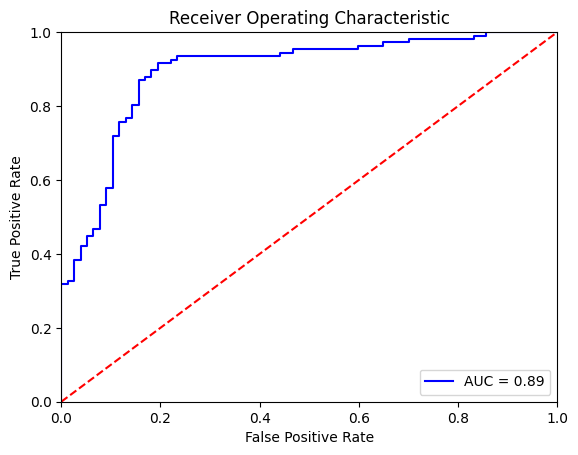

In [23]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('HeartDisease', axis =1),
                                                    df['HeartDisease'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({1:1, 2:0})
# y_test = y_test.replace({1:1, 2:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('mps')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=00,
    learning_rate = 0.1,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

  0%|          | 0/240 [00:00<?, ?it/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.4955, 'grad_norm': 18.019582748413086, 'learning_rate': 2.0000000000000002e-07, 'epoch': 0.83}


  0%|          | 0/3 [00:00<?, ?it/s]

{'eval_loss': 0.41165170073509216, 'eval_roc_auc': 0.895375652384998, 'eval_runtime': 2.9672, 'eval_samples_per_second': 62.011, 'eval_steps_per_second': 1.011, 'epoch': 1.0}


...

  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.8899521531100478
test precision 0.9117647058823529
test recall 0.8691588785046729
test accuracy 0.875
test roc_auc 0.9300886029857992



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/12 [00:00<?, ?it/s]

train f1 0.9060240963855422
train precision 0.8764568764568764
train recall 0.9376558603491272
train accuracy 0.8937329700272479
train roc_auc 0.9511057191855197


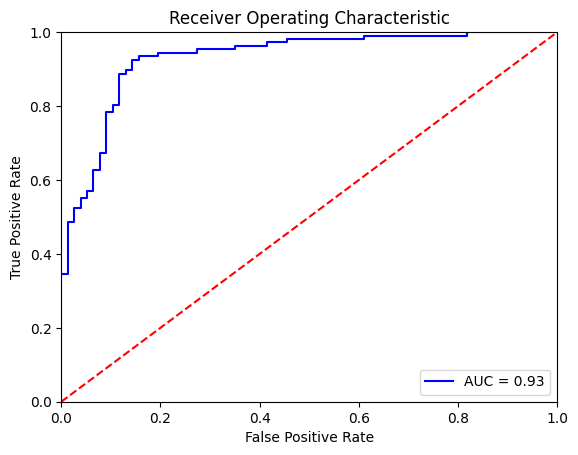

In [24]:
for param in model.bert.parameters():
    param.requires_grad = True

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=20,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=500,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

In [57]:
df = pd.read_csv('transfusion.data', sep=',')
print(len(df))

def concatenate_text(x_full):
    x = {}
    for i, j in x_full.items():
        x[i] = j if np.random.random() > DROP_P else '[UNK]'

    text = "".join([f"I have information about a blood donor. For the first time he donated blood {x['Time (months)']} months ago. ",
           f"Last time he donated blood {x['Recency (months)']} months ago. ",
           f"In total he donated blood {x['Frequency (times)']} times and donated {x['Monetary (c.c. blood)']} cubic centimeters of blood. ",
           f"Will this person donate blood in the next month?"])

    return text

X_train, X_test, y_train, y_test = train_test_split(df.drop('whether he/she donated blood in March 2007', axis =1),
                                                    df['whether he/she donated blood in March 2007'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({'yes': 1, 'no': 0})
# y_test = y_test.replace({'yes': 1, 'no': 0})

X_train['label'] = y_train
X_test['label'] = y_test

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

auc = evaluate.load("roc_auc")

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

748


Map:   0%|          | 0/598 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Map:   0%|          | 0/598 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.7533333333333333
test roc_auc 0.31667065295383884



/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [58]:
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score

scores = []
n_iter = 1000
multi = False
# thr = 0.5
y_pred = (pred[0][:, 1] <= thr).astype(int)
pred[0][:, 1] = 1 - pred[0][:, 1]
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.6824±0.0466',
 'F1': '0.3952±0.0435',
 'Accuracy': '0.2472±0.0339',
 'Precision': '0.2472±0.0339',
 'Recall': '1.0000±0.0000'}

In [69]:
df = pd.read_csv('german.data', sep=' ', names=['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5', 'Attribute6', 'Attribute7', 'Attribute8', 'Attribute9', 'Attribute10', 'Attribute11', 'Attribute12', 'Attribute13', 'Attribute14', 'Attribute15', 'Attribute16', 'Attribute17', 'Attribute18', 'Attribute19', 'Attribute20', 'class'])
print(len(df))

def concatenate_text(x_full):
    x = {}
    for i, j in x_full.items():
        x[i] = j if np.random.random() > DROP_P else '[UNK]'
    
    text = "".join([str(val) + ', ' for val in x.values()])

    return text

X_train, X_test, y_train, y_test = train_test_split(df.drop('class', axis =1),
                                                    df['class'],
                                                    test_size=.2,
                                                    random_state = 42)
y_train = y_train.replace({1:1, 2:0})
y_test = y_test.replace({1:1, 2:0})

X_train['label'] = y_train
X_test['label'] = y_test

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

auc = evaluate.load("roc_auc")

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

1000


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/4 [00:00<?, ?it/s]

test f1 0.8389057750759878
test precision 0.7340425531914894
test recall 0.9787234042553191
test accuracy 0.735
test roc_auc 0.8272628921745402



In [70]:
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score

scores = []
n_iter = 1000
multi = False
# thr = 0.5
y_pred = (pred[0][:, 1] >= thr).astype(int)
# pred[0][:, 1] = 1 - pred[0][:, 1]
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.8281±0.0304',
 'F1': '0.8383±0.0215',
 'Accuracy': '0.7346±0.0306',
 'Precision': '0.7336±0.0318',
 'Recall': '0.9790±0.0119'}

In [66]:
df = pd.read_csv('diabetes.csv')
print(len(df))

def concatenate_text(x_full):
    x = {}
    for i, j in x_full.items():
        x[i] = j if np.random.random() > DROP_P else '[UNK]'
    
    text = "".join([f"I have information about a woman. ",
            f"She has been pregnant {x['Pregnancies']} times. ",
            f"Her plasma glucose concentration in an oral glucose tolerance test is {x['Glucose']}. ",
            f"Her diastolic blood pressure is {x['BloodPressure']} (mm Hg). ",
            f"Her triceps skin fold thickness is {x['SkinThickness']} (mm). ",
            f"Her 2-Hour serum insulin is {x['Insulin']} (mu U/ml). ",
            f"Her body mass index is {x['BMI']}. ",
            f"Her diabetes pedigree function {x['DiabetesPedigreeFunction']}. ",
            f"Her age is {x['Age']} years old."])

    
    return text

X_train, X_test, y_train, y_test = train_test_split(df.drop('Outcome', axis =1),
                                                    df['Outcome'],
                                                    test_size=.2,
                                                    random_state = 42)

X_train['label'] = y_train
X_test['label'] = y_test

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

auc = evaluate.load("roc_auc")

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

768


Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.6021505376344086
test precision 0.7368421052631579
test recall 0.509090909090909
test accuracy 0.7597402597402597
test roc_auc 0.7869605142332414



In [68]:
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score

scores = []
n_iter = 1000
multi = False
# thr = 0.5
pred[0][:, 1] = 1 - pred[0][:, 1]
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.7891±0.0370',
 'F1': '0.6012±0.0609',
 'Accuracy': '0.7610±0.0345',
 'Precision': '0.7393±0.0733',
 'Recall': '0.5105±0.0683'}

In [63]:
df = pd.read_csv('heart.csv')
print(len(df))

def concatenate_text(x_full):
    x = {}
    for i, j in x_full.items():
        x[i] = j if np.random.random() > DROP_P else '[UNK]'

    if x['ChestPainType'] == 'TA':
        pt = 'Typical Angina'
    elif x['ChestPainType'] == 'ATA':
        pt = 'Atypical Angina'
    elif x['ChestPainType'] == 'NAP':
        pt = 'Non-Anginal Pain'
    elif x['ChestPainType'] == 'ASY':
        pt = 'Asymptomatic'
    else:
        pt = '[UNK]'

    if x['FastingBS'] == 1:
        bs = 'more than 120 mg/dl'
    elif x['FastingBS'] == 1:
        bs = 'less than 120 mg/dl'
    else:
        bs = '[UNK]'

    if x['RestingECG'] == 'Normal':
        ecg = 'Normal'
    elif x['RestingECG'] == 'ST':
        ecg = 'having ST-T wave abnormality'
    elif x['RestingECG'] == 'LVH':
        ecg = 'showing probable or definite left ventricular hypertrophy by Estes criteria'
    else:
        ecg = '[UNK]'
    
    text = "".join([f"I have information about a patient. ",
            f"He is {x['Age']} years old. ",
            f"His sex is {x['Sex']}. ",
            f"His chest pain type is {pt}. ",
            f"His resting blood pressure is {x['RestingBP']} (mm Hg). ",
            f"His serum cholesterol is {x['Cholesterol']} (mm/dl). ",
            f"His fasting blood sugar is {bs}. ",
            f"His resting electrocardiogram results are {ecg}. ",
            f"His maximum heart rate achieved is {x['MaxHR']}. ",
            f"His exercise-induced angina is {x['ExerciseAngina']}. ",
            f"His oldpeak {x['Oldpeak']}. ",
            f"His slope of the peak exercise ST segment is {x['ST_Slope']}."])

    
    return text

X_train, X_test, y_train, y_test = train_test_split(df.drop('HeartDisease', axis =1),
                                                    df['HeartDisease'],
                                                    test_size=.2,
                                                    random_state = 42)

X_train['label'] = y_train
X_test['label'] = y_test

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

auc = evaluate.load("roc_auc")

pred = trainer.predict(tokenized_test_dataset)
f1, thr = find_best_threshold(y_test, pred[0][:, 1])
print("test f1", f1)
print("test precision", precision_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test recall", recall_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
print("test accuracy", accuracy_score(y_test, (pred[0][:, 1] >= thr).astype(int)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

918


Map:   0%|          | 0/734 [00:00<?, ? examples/s]

Map:   0%|          | 0/184 [00:00<?, ? examples/s]

Map:   0%|          | 0/734 [00:00<?, ? examples/s]

Map:   0%|          | 0/184 [00:00<?, ? examples/s]

/Users/barebyxlol/Library/Python/3.9/lib/python/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  0%|          | 0/3 [00:00<?, ?it/s]

test f1 0.8542713567839196
test precision 0.9239130434782609
test recall 0.794392523364486
test accuracy 0.842391304347826
test roc_auc 0.9144313630294939



In [65]:
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score

scores = []
n_iter = 1000
multi = False
# thr = 0.5
pred[0][:, 1] = 1 - pred[0][:, 1]
y_pred = (pred[0][:, 1] >= thr).astype(int)
for i in range(n_iter):
    y_true_boot, y_pred_boot, y_prob_boot = resample(y_test, y_pred, pred[0][:, 1], random_state=i+1)
    try:
        if multi:
            auc = roc_auc_score(y_true_boot, y_prob_boot, multi_class="ovr", average="macro")
            f1 = f1_score(y_true_boot, y_pred_boot, average="macro")
            pr = precision_score(y_true_boot, y_pred_boot, average="macro", zero_division=0)
            rc = recall_score (y_true_boot, y_pred_boot, average="macro", zero_division=0)
        else:
            auc = roc_auc_score(y_true_boot, y_prob_boot)
            f1  = f1_score(y_true_boot, y_pred_boot)
            pr  = precision_score(y_true_boot, y_pred_boot, zero_division=0)
            rc  = recall_score (y_true_boot, y_pred_boot, zero_division=0)
        scores.append((auc, f1, accuracy_score(y_true_boot, y_pred_boot), pr, rc))
    except ValueError:
        continue
scores = np.asarray(scores)
means, stds = scores.mean(0), scores.std(0, ddof=1)
names = ["ROC-AUC", "F1", "Accuracy", "Precision", "Recall"]
{n: f"{m:.4f}±{s:.4f}" for n, m, s in zip(names, means, stds)}

{'ROC-AUC': '0.9142±0.0230',
 'F1': '0.8540±0.0271',
 'Accuracy': '0.8428±0.0268',
 'Precision': '0.9232±0.0287',
 'Recall': '0.7955±0.0389'}